---
# 📊 NARAHOTEIS - LIMPEZA E TRATAMENTO DE DADOS

#### 👨‍💼 Projeto de Análise e Preparação de Dados  

---

#### 🎯 Objetivo
Este notebook tem como objetivo realizar a **auditoria, limpeza e tratamento dos dados** provenientes do sistema da NaraHoteis, com foco na correção de inconsistências e padronização das informações.

---

#### 🧠 Contexto
A base de dados analisada apresenta diversos problemas estruturais, como:

- Variações de escrita em campos categóricos  
- Valores inválidos (negativos, fora de escala, duplicados)  
- Dados em formatos inconsistentes  
- Presença de valores nulos  

Esses problemas impactam diretamente a qualidade das análises e podem levar a interpretações incorretas.

---

#### 🔧 Escopo do Trabalho
As seguintes bases foram analisadas e tratadas:

- Reservas  
- Unidades  
- Tipos de quarto  
- Funcionários  
- Clientes  
- Canais de venda  

---

#### 📌 Metodologia

O processo aplicado neste notebook segue as etapas:

1. 🔍 **Auditoria**  
   Verificação inicial da base (estrutura, nulos, duplicatas e inconsistências)

2. 🧹 **Limpeza**  
   Correção de problemas como:
   - Padronização de textos  
   - Remoção de inconsistências  
   - Ajuste de formatos  

3. 🔧 **Tratamento**  
   Aplicação de regras de negócio:
   - Correção de valores inválidos  
   - Conversão de tipos (datas, números)  
   - Ajustes baseados em comunicados oficiais  

4. ✅ **Validação**  
   Conferência dos dados após tratamento  

5. 💾 **Exportação**  
   Geração das bases tratadas para uso em análise  

---

#### ✅ Checklist Aplicado

- [x] Verificação de estrutura (`shape`, `info`)  
- [x] Identificação de valores nulos  
- [x] Verificação de duplicatas  
- [x] Padronização de campos textuais  
- [x] Conversão de tipos de dados  
- [x] Correção de valores inconsistentes  

---

#### 📊 Resultado Esperado

Após o tratamento, os dados tornam-se:

- ✅ Padronizados  
- ✅ Consistentes  
- ✅ Prontos para análise  

---

#### 📘 Referências

- Comunicado Oficial NaraHoteis (COM-2025-047)  
- Boas práticas de limpeza e tratamento de dados.

---
# 📊 IMPORTAÇÕES

- pandas: manipulação e tratamento de dados
- numpy: operações numéricas  
- matplotlib: criação de gráficos  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---
# 🏨 Base: reservas.csv

### ✅ Problemas Identificados e Ações

`Base: reservas.csv | Campo: status_reserva`
- Problema: Variações de escrita para o mesmo valor (ex: 'confirmada', 'Confirmada',
'CONFIRMADA ', 'conf.')
- Ação: Padronizar todos os valores para o padrão oficial informado no Comunicado:
Confirmada, Cancelada, No-Show, Concluída.

`Base: reservas.csv | Campo: forma_pagamento`
- Problema: Abreviações e variações inconsistentes (ex: 'CC', 'cartao credito', 'Cartão de
Crédito', 'cred')
- Ação: Padronizar todos os valores para o padrão oficial: Cartão de Crédito, Cartão de Débito,
PIX, Dinheiro, Transferência.

`Base: reservas.csv | Campo: id_canal`
- Problema: Valores nulos (~5% dos registros)
- Ação: Manter os nulos. Estes registros representam reservas antigas realizadas antes da
implantação do controle por canal.

### ✅ Resultado do Tratamento — status_reserva

Após a aplicação do mapeamento, os valores do campo foram padronizados conforme o padrão definido.

Os status agora apresentam consistência, permitindo análises mais confiáveis sobre o comportamento das reservas.

In [2]:

df_reserva = pd.read_csv('reservas.csv', sep=';')

shape_inicial = df_reserva.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_reserva.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_reserva.shape[0]:>16}')
print(f'Colunas originais:      {df_reserva.shape[1]:>16}')
print(f'Colunas finais:         {df_reserva.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_reserva.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_reserva.duplicated().sum():>16}')
print('=' * 40)


# ALTERAÇÃO DOS STATUS
#Confirmada, Cancelada, No-Show, Concluída.
df_reserva = pd.read_csv('reservas.csv', sep=';')

mapa = {
    'confirmada':           'Confirmada',
    'concluída':            'Concluída',
    'Concluída':            'Concluída',
    'cancel.':              'Cancelada',
    'CONFIRMADA':           'Confirmada',
    'Concluida':            'Concluída',
    'CANCELADA':            'Cancelada',
    'cancelada':            'Cancelada',
    'no-show':              'No-Show',
    'NO-SHOW':              'No-Show',
    'conf.':                'Confirmada',
    'cancelada':            'Cancelada',
    'CONFIRMADA ':          'Confirmada',
    'Concluída ':           'Concluída',}



df_reserva['status_reserva'] = df_reserva['status_reserva'].map(mapa).fillna(df_reserva['status_reserva'])

print('\nApós mapeamento:')
print(sorted(df_reserva['status_reserva'].unique()))

####df_reserva.head(50)




##############################
#ALTERAÇÃO DOS FORMA_PAGAMENTO
mapa1 = {
    'CC':                   'Cartão de Crédito',
    'CD':                   'Cartão de Débito',
    'Pix':                  'PIX',
    'cash':                 'Dinheiro',
    'cartao debito':        'Cartão de Débito',
    'C. Crédito':           'Cartão de Crédito',
    'cred':                 'Cartão de Crédito',
    'DINHEIRO':             'Dinheiro',
    'TED':                  'Transferência',
    'déb':                  'Cartão de Débito',
    'transferencia':        'Transferência',
    'ted':                  'Transferência',
    'cartao credito':       'Cartão de Crédito',
    'pix':                  'PIX',
    'dinheiro':             'Dinheiro'}


df_reserva['forma_pagamento'] = df_reserva['forma_pagamento'].map(mapa1).fillna(df_reserva['forma_pagamento'])
print('\nApós mapeamento:')
print(sorted(df_reserva['forma_pagamento'].unique()))

################ TRATANDO CAMPOS DATA_CHECKIN E DATA_CHECKOUT

df_reserva['data_checkin'] = pd.to_datetime(df_reserva['data_checkin'], errors='coerce')

df_reserva['data_checkout'] = pd.to_datetime(df_reserva['data_checkout'], errors='coerce')


# Tipos de cada coluna
display(df_reserva.dtypes)
df_reserva

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                 2457
Registros finais:                   2457
Registros removidos:                   0
Colunas originais:                    12
Colunas finais:                       12
Nulos restantes:                     449
Duplicatas restantes:                  0

Após mapeamento:
['Cancelada', 'Concluída', 'Confirmada', 'No-Show']

Após mapeamento:
['Cartão de Crédito', 'Cartão de Débito', 'Dinheiro', 'PIX', 'Transferência']


id_reserva                    int64
id_unidade                    int64
id_tipo_quarto                int64
id_cliente                    int64
id_canal                    float64
data_checkin         datetime64[us]
data_checkout        datetime64[us]
qtd_diarias                   int64
num_hospedes                  int64
avaliacao_hospede           float64
status_reserva                  str
forma_pagamento                 str
dtype: object

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,Cancelada,PIX
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,2453,10,3,210,4.0,2023-10-22,2023-10-27,5,1,9.0,Confirmada,Cartão de Débito
2453,2454,7,3,271,2.0,2024-08-08,2024-08-14,6,2,6.0,Confirmada,PIX
2454,2455,7,1,143,1.0,2023-07-26,2023-07-27,1,2,6.0,Confirmada,Transferência
2455,2456,8,4,176,1.0,2023-05-10,2023-05-17,7,1,6.0,Concluída,Cartão de Débito


`Base: reservas.csv | Campo: qtd_diarias`
- Problema: Valores impossíveis: 0 e -1
- Ação: Substituir pelos valores corretos informados no Comunicado Oficial (COM-2025-047)


In [3]:
######QUANTIDADE DE DIÁRIAS (QTD_DIARIAS)
df_reserva.iloc[954, 7] = 4
df_reserva.iloc[727, 7] = 4
df_reserva.iloc[1133, 7] = 2
df_reserva.iloc[1151, 7] = 5
df_reserva.iloc[1447, 7] = 2
df_reserva.iloc[1580, 7] = 2
df_reserva.iloc[2311, 7] = 2
df_reserva.iloc[2383, 7] = 2

lista_ids = [728, 955,1134, 1152, 1448, 1581, 2312, 2384]
df_filtrado = df_reserva[df_reserva['id_reserva'].isin(lista_ids)]
print(df_filtrado)
df_reserva

      id_reserva  id_unidade  id_tipo_quarto  id_cliente  id_canal  \
727          728           4               4         120       1.0   
954          955           7               3         211       2.0   
1133        1134           5               1         125       4.0   
1151        1152           5               2          59       4.0   
1447        1448           8               3          52       1.0   
1580        1581          10               3         280       2.0   
2311        2312           8               2         138       4.0   
2383        2384           5               2          64       2.0   

     data_checkin data_checkout  qtd_diarias  num_hospedes  avaliacao_hospede  \
727    2023-09-22    2023-09-29            4             4                NaN   
954    2023-07-12    2023-07-16            4             1                9.0   
1133   2023-07-08    2023-07-11            2             2                2.0   
1151   2023-10-15    2023-10-17            5 

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,Concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,Concluída,Cartão de Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,Cancelada,PIX
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,2453,10,3,210,4.0,2023-10-22,2023-10-27,5,1,9.0,Confirmada,Cartão de Débito
2453,2454,7,3,271,2.0,2024-08-08,2024-08-14,6,2,6.0,Confirmada,PIX
2454,2455,7,1,143,1.0,2023-07-26,2023-07-27,1,2,6.0,Confirmada,Transferência
2455,2456,8,4,176,1.0,2023-05-10,2023-05-17,7,1,6.0,Concluída,Cartão de Débito


`Base: reservas.csv | Campo: avaliacao_hospede`
- Problema: Valores fora da escala permitida (0, 11, -3) — escala válida: 1 a 10
- Ação: Substituir pelos valores corretos informados no Comunicado Oficial (COM-2025-047)

In [4]:
######AVALIAÇÃO DO HÓSPEDE (AVALIACAO_HOSPEDE)

df_reserva.iloc[36, 9] =   8
df_reserva.iloc[193, 9] =  2
df_reserva.iloc[901, 9] =  10
df_reserva.iloc[932, 9] =  7
df_reserva.iloc[1537, 9] = 3
df_reserva.iloc[1717, 9] = 4
df_reserva.iloc[1865, 9] = 3
df_reserva.iloc[2072, 9] = 9
df_reserva.iloc[2166, 9] = 5
df_reserva.iloc[2209, 9] = 2

lista_ids = [37, 194,902, 933, 1538, 1718, 1866, 2073]
df_filtrado_avaliacao = df_reserva[df_reserva['id_reserva'].isin(lista_ids)]
df_filtrado_avaliacao

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
36,37,7,3,150,1.0,2023-01-09,2023-01-11,2,1,8.0,Concluída,Cartão de Débito
193,194,7,1,228,2.0,2023-07-31,2023-08-04,4,1,2.0,Concluída,PIX
901,902,8,3,193,2.0,2024-11-05,2024-11-11,6,3,10.0,Confirmada,Transferência
932,933,3,4,196,3.0,2024-05-07,2024-05-08,1,4,7.0,No-Show,Cartão de Crédito
1537,1538,12,1,31,3.0,2024-04-23,2024-04-26,3,2,3.0,Confirmada,Cartão de Débito
1717,1718,12,1,54,4.0,2024-07-20,2024-07-21,1,1,4.0,Confirmada,Dinheiro
1865,1866,7,3,263,4.0,2024-04-07,2024-04-09,2,2,3.0,Concluída,Dinheiro
2072,2073,10,1,88,2.0,2023-06-06,2023-06-08,2,1,9.0,Confirmada,Cartão de Débito


`Base: reservas.csv | Campo: num_hospedes`
- Problema: Valores negativos
- Ação: Substituir pelos valores corretos informados no Comunicado Oficial (COM-2025-047).

In [5]:
######NÚMERO DE HÓSPEDES (NUM_HOSPEDES)

df_reserva.iloc[567, 8] =  2
df_reserva.iloc[674, 8] =  3
df_reserva.iloc[902, 8] =  2
df_reserva.iloc[1200, 8] = 3
df_reserva.iloc[1882, 8] = 1
df_reserva.iloc[2426, 8] = 1

lista_ids = [568, 675,903, 1201, 1883, 2427]
df_filtrado_hospedes = df_reserva[df_reserva['id_reserva'].isin(lista_ids)]

df_reserva

######################## EXPORT BASE TRATADA ####################

df_reserva.to_csv('df_reserva_clean.csv', sep=';', index=False)
print('✅ Base exportada: df_reserva_clean.csv')

✅ Base exportada: df_reserva_clean.csv


---
# 🏢 Base: unidades.csv

`Base: unidades.csv | Campo: regiao`
- Problema: Variações de escrita ('capital', 'CAP', 'Cap.', 'Baixada fluminense', 'Serra ')
- Ação: Padronizar para os 4 valores oficiais: Capital, Baixada Fluminense, Serra, Costa
Verde.


`Base: unidades.csv | Campo: categoria_hotel`
- Problema: Variações de escrita ('3*', 'Três Estrelas', '4 Estrelas', 'cinco estrelas')
- Ação: Padronizar para: 3 estrelas, 4 estrelas, 5 estrelas.


`Base: unidades.csv | Campo: num_quartos_total`
- Problema: 2 valores nulos
- Ação: Consultar a fonte oficial para obter os valores corretos. Não preencher com média,
mediana ou estimativa.

In [6]:
df_unidades = pd.read_csv('unidades.csv', sep=';')

shape_inicial = df_unidades.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_unidades.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_unidades.shape[0]:>16}')
print(f'Colunas originais:      {df_unidades.shape[1]:>16}')
print(f'Colunas finais:         {df_unidades.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_unidades.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_unidades.duplicated().sum():>16}')
print('=' * 40)


#####PADRONIZAÇÃO DE CAMPOS TEXTUAIS ---- REGIAO

mapa4 = {
    'Capital':                  'Capital',
    'Baixada Fluminense':       'Baixada Fluminense',
    'Serra':                    'Serra',
    'Baixada fluminense':       'Baixada Fluminense',
    'CAP':                      'Capital',
    'Serra':                    'Serra',
    'capital':                  'Capital',}

df_unidades['regiao'] = df_unidades['regiao'].map(mapa4).fillna(df_unidades['regiao'])


print('Após mapeamento:')
print(sorted(df_unidades['regiao'].unique()))

######PADRONIZAÇÃO DE CAMPOS TEXTUAIS --- CATEGORIA_HOTEL
mapa5 = {
    '3*':               '3 estrelas',
    '4 Estrelas':       '4 estrelas',
    '3*':               '3 estrelas',
    '4 Estrelas':       '4 estrelas',
    'Três Estrelas':    '3 estrelas',
    'cinco estrelas':   '5 estrelas',
    '4 Estrelas':       '4 estrelas',}


df_unidades['categoria_hotel'] = df_unidades['categoria_hotel'].map(mapa5).fillna(df_unidades['categoria_hotel'])

print('Após mapeamento:')
print(sorted(df_unidades['categoria_hotel'].unique()))

#### Alteração de campo num_quartos_total    
df_unidades['num_quartos_total'] = df_unidades['num_quartos_total'].fillna(0).astype(int)

#######################################################################################
##########UNIDADES.CSV | CAMPO: NUM_QUARTOS_TOTAL  ---PROBLEMA: 2 VALORES NULOS

df_unidades.iloc[6, 5] = 70
df_unidades.iloc[9, 5] = 65

lista_ids = [7, 10]
df_filtrado_unidades = df_unidades[df_unidades['id_unidade'].isin(lista_ids)]
df_unidades
##Tipos de campos
display(df_unidades.dtypes)

df_unidades

######################## EXPORT BASE TRATADA ####################
df_unidades.to_csv('df_unidades_clean.csv', sep=';', index=False)
print('✅ Base exportada: df_unidades_clean.csv')

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                   12
Registros finais:                     12
Registros removidos:                   0
Colunas originais:                     6
Colunas finais:                        6
Nulos restantes:                       2
Duplicatas restantes:                  0
Após mapeamento:
['Baixada Fluminense', 'Capital', 'Costa Verde', 'Serra', 'Serra ']
Após mapeamento:
['3 estrelas', '4 estrelas', '5 estrelas']


id_unidade           int64
nome_unidade           str
cidade                 str
regiao                 str
categoria_hotel        str
num_quartos_total    int64
dtype: object

✅ Base exportada: df_unidades_clean.csv


---
# 🛏️ Base: tipos_quarto.csv

`Base: tipos_quarto.csv | Campo: descricao`
- Problema: Variações de caixa e espaços ('STANDARD', 'superior ', 'Deluxe')
- Ação: Padronizar para: Standard, Superior, Deluxe, Suite, Suíte Master.


`Base: tipos_quarto.csv | Campo: valor_diaria_base`
- Problema: Valor numérico armazenado como texto com símbolo de moeda ('R$ 280,00')
- Ação: Remover o prefixo 'R$ ', substituir vírgula por ponto e converter para tipo numérico
decimal.

- Remove duplicatas baseadas na coluna 'Chave'

In [7]:
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')

print(df_tipos_quarto.shape)

#####df_tipos_quarto.head(20)

shape_inicial = df_tipos_quarto.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_tipos_quarto.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_tipos_quarto.shape[0]:>16}')
print(f'Colunas originais:      {df_tipos_quarto.shape[1]:>16}')
print(f'Colunas finais:         {df_tipos_quarto.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_tipos_quarto.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_tipos_quarto.duplicated().sum():>16}')
print('=' * 40)


#####Padronização de campos textuais ---- descricao

mapa6 = {
    'STANDARD':         'Standard',
    'superior':         'Superior',
    'Deluxe':           'Deluxe',
    'superior':         'Superior'}


df_tipos_quarto['descricao'] = df_tipos_quarto['descricao'].map(mapa6).fillna(df_tipos_quarto['descricao'])


print('\nApós mapeamento:')
print(sorted(df_tipos_quarto['descricao'].unique()))

df_tipos_quarto

df_tipos_quarto['valor_diaria_base'] = df_tipos_quarto['valor_diaria_base'].astype(str).str.replace('R$', '').str.replace('.', '').str.replace("'", "").str.replace(",", ".").astype(float)

print('Tipo:', df_tipos_quarto['valor_diaria_base'].dtype)

##print('Nulos gerados:', df_tipos_quarto['valor_diaria_base'].isnull().sum())


##Tipos de campos
display(df_tipos_quarto.dtypes)


df_tipos_quarto


######################## Export base tratada ####################
##df_tipos_quarto.to_csv('df_tipos_quarto_clean.csv', sep=';', index=False)
###print('✅ Base exportada: df_tipos_quarto_clean.csv')



######Chaves Duplicadas#########################

# Remove duplicatas baseadas na coluna 'Chave'
##df_limpo = df.drop_duplicates(subset=['Chave'], keep='first')
df_tipo_quarto_limpo = df_tipos_quarto.drop_duplicates(subset=['id_tipo_quarto'], keep='first')
###print(df_tipo_quarto_limpo)
###df_tipo_quarto_limpo
df_tipo_quarto_limpo.to_csv('df_tipos_quarto_clean_1.csv', sep=';', index=False)


(6, 4)
         RELATÓRIO DE AUDITORIA         
Registros iniciais:                    6
Registros finais:                      6
Registros removidos:                   0
Colunas originais:                     4
Colunas finais:                        4
Nulos restantes:                       0
Duplicatas restantes:                  1

Após mapeamento:
['Deluxe', 'Standard', 'Suite', 'Suíte Master', 'superior ']
Tipo: float64


id_tipo_quarto         int64
descricao                str
capacidade_max         int64
valor_diaria_base    float64
dtype: object

---
# 👨‍💼 Base: funcionarios.csv

`Base: funcionarios.csv | Campo: salario`
- Problema: 1 outlier extremo (999.999,00) — id_funcionario 26
- Ação: Substituir pelo valor correto informado no Comunicado Oficial (COM-2025-047): R$
2.300,00.

`Base: funcionarios.csv | Campo: salario`
- Problema: 1 valor negativo (-2.800,00) — id_funcionario 11
- Ação: Substituir pelo valor correto informado no Comunicado Oficial (COM-2025-047): R$
1.950,00.


`Base: funcionarios.csv | Campo: cargo`
- Problema: Variações de caixa e espaços ('RECEPCIONISTA', 'camareira', 'Gerente ')
- Ação: Padronizar caixa e remover espaços extras. Usar o padrão com inicial maiúscula (ex:
Recepcionista, Camareira, Gerente).


`Base: funcionarios.csv | Campo: departamento`
- Problema: Abreviações inconsistentes ('Admin.', 'A&B;', 'Gov.')
- Ação: Padronizar para os nomes completos oficiais: Administração, Alimentos e Bebidas,
Governança, etc.

`Base: funcionarios.csv | Campo: salario`
- Problema: ~5 valores nulos
- Ação: Manter os nulos após a conversão de tipo. Não preencher com média ou mediana.

`Base: funcionarios.csv | Campo: salario`
- Problema: Valor numérico armazenado como texto com aspas e separador de milhar
('"3.500,00"')
- Ação: Remover aspas, remover separador de milhar (ponto), substituir vírgula decimal por
ponto e converter para numérico.

In [8]:

df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')

df_funcionarios.head(20)


shape_inicial = df_funcionarios.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_funcionarios.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_funcionarios.shape[0]:>16}')
print(f'Colunas originais:      {df_funcionarios.shape[1]:>16}')
print(f'Colunas finais:         {df_funcionarios.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_funcionarios.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_funcionarios.duplicated().sum():>16}')
print('=' * 40)


######Número de funcionarios (salario)

df_funcionarios.iloc[10, 5] = "1.950,00"
df_funcionarios.iloc[25, 5] = "2.300,00"


lista_ids = [11, 26]
df_filtrado_funcionarios = df_funcionarios[df_funcionarios['id_funcionario']
                                           .isin(lista_ids)]
df_filtrado_funcionarios

#####Variações de caixa e espaços ('RECEPCIONISTA', 'camareira', 'Gerente ')
mapa7 = {
    'RECEPCIONISTA':                'Recepcionista',
    'camareira':                    'Camareira',
    'Gerente':                      'Gerente',
    'ANALISTA FINANCEIRO':          'Analista Financeiro',
    'AUXILIAR DE LIMPEZA':          'Auxiliar de Limpeza',
    'CAMAREIRA':                    'Camareira',
    'Camareira':                    'Camareira',
    'CAMAREIRA':                    'Camareira',
    'COZINHEIRO':                   'Cozinheiro',
    'MANUTENÇÃO':                   'Manutenção',
    'Manutenção':                   'Manutenção',
    'Recepcionista':                'Recepcionista',
    'SEGURANÇA':                    'Segurança',
    'analista financeiro':          'Analista Financeiro',
    'cozinheiro':                   'Cozinheiro',
    'gerente':                      'Gerente',
    'segurança':                    'Segurança',
    'recepcionista':                'Recepcionista',
    'manutenção':                   'Manutenção'}




df_funcionarios['cargo'] = df_funcionarios['cargo'].map(mapa7).fillna(df_funcionarios['cargo'])


print('\nApós mapeamento:')
print(sorted(df_funcionarios['cargo'].unique()))


##### Abreviações inconsistentes ('Admin.', 'A&B;', 'Gov.')
mapa8 = {
    'Admin.':       'Administração',
    'Gov.':         'Governança',
    'A&B':          'Alimentos e Bebidas',}
    
df_funcionarios['departamento'] = df_funcionarios['departamento'].map(mapa8).fillna(df_funcionarios['departamento'])

print('\nApós mapeamento:')
print(sorted(df_funcionarios['departamento'].unique()))
##df_funcionarios



df_funcionarios['salario'] = df_funcionarios['salario'].astype(str).str.replace('"', '').str.replace('.', '').str.replace("'", "").str.replace(",", ".").astype(float)

###print('Tipo:', df_funcionarios['salario'].dtype)

###print('Nulos gerados:', df_funcionarios['salario'].isnull().sum())

df_funcionarios.head(15)

# Ver QUAIS linhas têm pelo menos um nulo
df_funcionarios[df_funcionarios.isnull()     # Gera True/False para cada dado (True = nulo)
   .any(axis=1)]   # any(): existe pelo menos um True? axis=1: por linha
df_funcionarios
##Tipos de campos
display(df_funcionarios.dtypes)

df_funcionarios


######################## Export base tratada ####################
df_funcionarios.to_csv('df_funcionarios_clean.csv', sep=';', index=False)
print('\n✅ Base exportada: df_funcionarios_clean.csv')

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                  134
Registros finais:                    134
Registros removidos:                   0
Colunas originais:                     7
Colunas finais:                        7
Nulos restantes:                       6
Duplicatas restantes:                  0

Após mapeamento:
['Analista Financeiro', 'Auxiliar de Limpeza', 'Camareira', 'Camareira ', 'Cozinheiro', 'Gerente', 'Manutenção', 'Manutenção ', 'Recepcionista', 'Recepcionista ', 'Segurança']

Após mapeamento:
['Administração', 'Alimentos e Bebidas', 'Financeiro', 'Governança', 'Manutenção', 'Recepção', 'Segurança']


id_funcionario      int64
id_unidade          int64
nome                  str
cargo                 str
departamento          str
salario           float64
data_admissao         str
dtype: object


✅ Base exportada: df_funcionarios_clean.csv


---
# 👥 Base: clientes.csv

`Base: clientes.csv | Campo: estado_origem`
- Problema: Variações para o mesmo estado ('RJ', 'Rio de Janeiro', 'r.j.', 'rj')
- Ação: Padronizar para a sigla oficial de 2 letras em maiúsculo (ex: RJ, SP, MG).


`Base: clientes.csv | Campo: tipo_cliente`
- Problema: Variações inconsistentes ('PF', 'pessoa fisica', 'pf', 'PJ', 'corporativo')
- Ação: Padronizar para: Pessoa Física, Corporativo.

`Base: clientes.csv | Campo: nome`
- Problema: Espaços extras no início e/ou fim do campo
- Ação: Aplicar remoção de espaços extras em todo o campo.


- Remove duplicatas baseadas na coluna 'Chave'

In [9]:
df_clientes = pd.read_csv('clientes.csv', sep=';')

shape_inicial = df_clientes.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_clientes.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_clientes.shape[0]:>16}')
print(f'Colunas originais:      {df_clientes.shape[1]:>16}')
print(f'Colunas finais:         {df_clientes.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_clientes.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_clientes.duplicated().sum():>16}')
print('=' * 40)

###### Variações para o mesmo estado ('RJ', 'Rio de Janeiro', 'r.j.', 'rj')

mapa9 = {
    'Rio de Janeiro':       'RJ',
    'r.j.':                 'RJ',
    'rj':                   'RJ',}
    
df_clientes['estado_origem'] = (df_clientes['estado_origem']
                                .map(mapa9)
                                .fillna(df_clientes['estado_origem']))


print('\nApós mapeamento:')
print(sorted(df_clientes['estado_origem'].unique()))


###Variações inconsistentes ('PF', 'pessoa fisica', 'pf', 'PJ', 'corporativo')
mapa10 = {
    'PF':                     'Pessoa Física',
    'pessoa fisica':                'Pessoa Física',
    'pf':   'Pessoa Física',
    'PJ':  'Corporativo',
    'corporativo':                      'Corporativo',}
    
df_clientes['tipo_cliente'] = df_clientes['tipo_cliente'].map(mapa10).fillna(df_clientes['tipo_cliente'])


print('\nApós mapeamento:')
print(sorted(df_clientes['tipo_cliente'].unique()))


df_clientes['nome'] = df_clientes['nome'].astype(str).str.replace('"', '').str.replace(' ', '').str.replace("'", "").str.replace("  ", "")

print('\nTipo:', df_clientes['nome'].dtype)

print('\nnNulos gerados:', df_clientes['nome'].isnull().sum())
df_clientes


##Tipos de campos
####display(df_clientes.dtypes)

###df_clientes




##########LINHAS DUPLICADAS#####################

###linhas_duplicadas = df_clientes[df_clientes.duplicated(keep=False)]
###
###print(linhas_duplicadas)


df_limpo_cliente = df_clientes.drop_duplicates(subset=['id_cliente'], keep='first')



######################## Export base tratada ####################
df_limpo_cliente.to_csv('df_limpo_cliente_clean_2.csv', sep=';', index=False)
print('\n✅ Base exportada: df_clientes_clean.csv')

         RELATÓRIO DE AUDITORIA         
Registros iniciais:                  301
Registros finais:                    301
Registros removidos:                   0
Colunas originais:                     6
Colunas finais:                        6
Nulos restantes:                      29
Duplicatas restantes:                  0

Após mapeamento:
['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MG', 'PA', 'PE', 'PR', 'RJ', 'RS', 'SC', 'SP']

Após mapeamento:
['Corporativo', 'Pessoa Física']

Tipo: str

nNulos gerados: 0

✅ Base exportada: df_clientes_clean.csv


---
# 📞 Base: canais_venda.csv

`Base: canais_venda.csv | Campo: nome_canal`
- Problema: Variações de escrita ('ota', 'agencia')
- Ação: Padronizar para: Site Próprio, OTA, Telefone, Agência.


In [10]:
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')

###print(df.shape)
shape_inicial = df_canais_venda.shape[0]

print('=' * 40)
print('RELATÓRIO DE AUDITORIA'.center(40))
print('=' * 40)
print(f'Registros iniciais:     {shape_inicial:>16}')
print(f'Registros finais:       {df_canais_venda.shape[0]:>16}')
print(f'Registros removidos:    {shape_inicial - df_canais_venda.shape[0]:>16}')

print(f'Colunas originais:      {df_canais_venda.shape[1]:>16}')
print(f'Colunas finais:         {df_canais_venda.shape[1]:>16}')
print('=' * 40)
print(f'Nulos restantes:        {df_canais_venda.isnull().sum().sum():>16}')
print(f'Duplicatas restantes:   {df_canais_venda.duplicated().sum():>16}')
print('=' * 40)

######Variações de escrita ('ota', 'agencia')
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')
###df_canais_venda
mapa10 = {
    'ota':          'OTA',
    'agencia':      'Agência',}
    
df_canais_venda['nome_canal'] = df_canais_venda['nome_canal'].map(mapa10).fillna(df_canais_venda['nome_canal'])


print('\nApós mapeamento:')
print(sorted(df_canais_venda['nome_canal'].unique()))


         RELATÓRIO DE AUDITORIA         
Registros iniciais:                    4
Registros finais:                      4
Registros removidos:                   0
Colunas originais:                     3
Colunas finais:                        3
Nulos restantes:                       0
Duplicatas restantes:                  0

Após mapeamento:
['Agência', 'OTA', 'Site Próprio', 'Telefone']


`Base: canais_venda.csv | Campo: comissao_pct`
- Problema: Valor numérico armazenado como texto com símbolo de percentual ('12%', '8%')
- Ação: Remover o símbolo '%' e converter para tipo numérico decimal.

In [11]:
### Corrigindo Tipos: strings, números e datas

# Passo 1: limpar conteúdo 
df_canais_venda['comissao_pct'] = df_canais_venda['comissao_pct'].astype(str).str.replace('%', '').str.replace(',', '.')

# Passo 2: converter tipo
df_canais_venda['comissao_pct'] = pd.to_numeric(df_canais_venda['comissao_pct'], errors='coerce')

print('\nTipo:', df_canais_venda['comissao_pct'].dtype)
print('\nNulos gerados:', df_canais_venda['comissao_pct'].isnull().sum())

print('\n')
print(df_canais_venda)

display(df_canais_venda.dtypes)


######################## Export base tratada ####################
df_canais_venda.to_csv('df_canais_venda_clean.csv', sep=';', index=False)
print('\n✅ Base exportada: df_canais_venda_clean.csv')


Tipo: int64

Nulos gerados: 0


   id_canal    nome_canal  comissao_pct
0         1  Site Próprio             8
1         2           OTA            18
2         3      Telefone             5
3         4       Agência            12


id_canal        int64
nome_canal        str
comissao_pct    int64
dtype: object


✅ Base exportada: df_canais_venda_clean.csv


---
# 📊 GRAFICOS

- Com base nas bases tratadas, foram gerados gráficos para responder perguntas de negócio relacionadas ao comportamento das reservas, preferência de clientes e nível de ocupação.

## 📌 Insights e Respostas

- Apesar do alto número de reservas confirmadas, nem todas são convertidas em hospedagens efetivas (concluídas), indicando perdas por cancelamento e no-show  

- A distribuição das formas de pagamento evidencia o comportamento dos clientes e pode impactar custos operacionais  

- A variação no número de hóspedes indica diferentes perfis de utilização (individual, casal ou grupo)  

- As avaliações mostram o nível geral de satisfação, podendo indicar oportunidades de melhoria na experiência do cliente  

✅ Os dados permitem compreender o comportamento das reservas e apoiar decisões operacionais e estratégicas da rede.

✅ ✅ 1. GRÁFICO — STATUS DAS RESERVAS (cancelamento / operação)

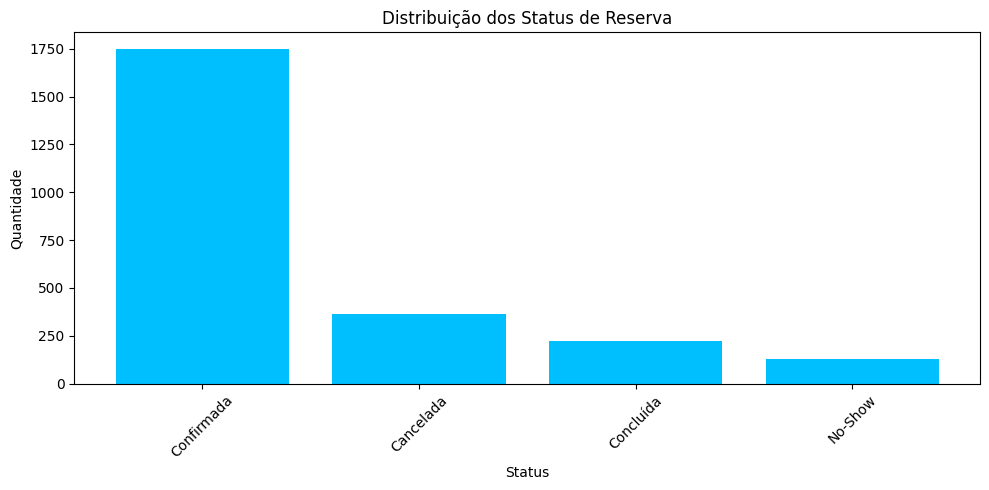

In [12]:
plt.figure(figsize=(10,5))

status_counts = df_reserva['status_reserva'].value_counts()

plt.bar(status_counts.index, status_counts.values, color='#00BFFF')

plt.title('Distribuição dos Status de Reserva')
plt.xlabel('Status')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

✅ ✅ 2. GRÁFICO — FORMAS DE PAGAMENTO (comportamento do cliente)

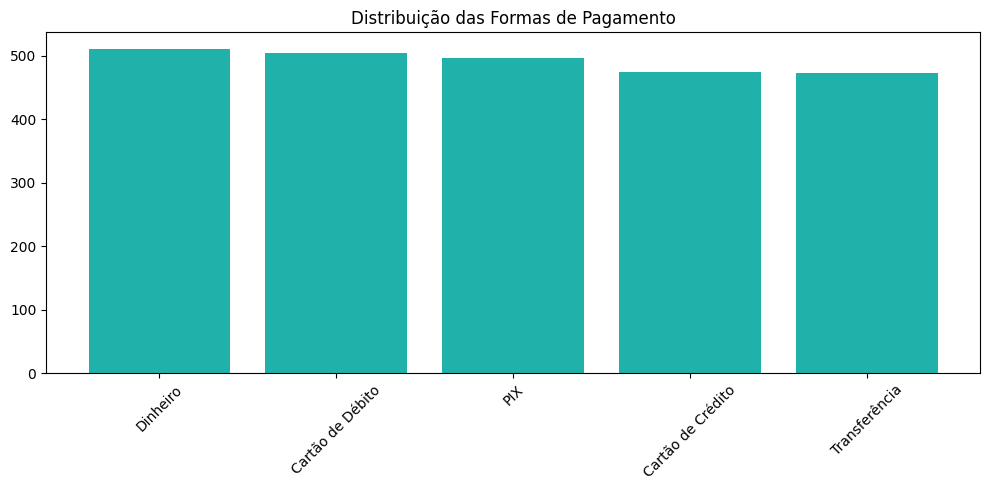

In [13]:
plt.figure(figsize=(10,5))

pagamento_counts = df_reserva['forma_pagamento'].value_counts()

plt.bar(pagamento_counts.index, pagamento_counts.values, color='#20B2AA')

plt.title('Distribuição das Formas de Pagamento')
#plt.xlabel('Forma de Pagamento')
#plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

✅ ✅ 3. GRÁFICO — HÓSPEDES (BOXPLOT) (padrão de ocupação)

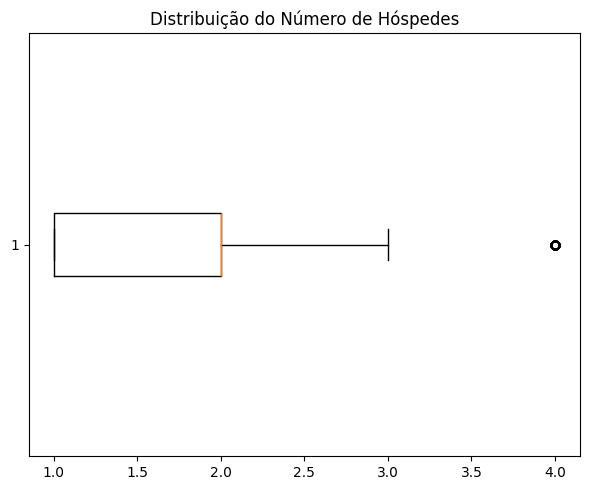

In [14]:
plt.figure(figsize=(6,5))

plt.boxplot(df_reserva['num_hospedes'],vert=False)

plt.title('Distribuição do Número de Hóspedes')

plt.tight_layout()
plt.show()

✅ ✅ 4. GRÁFICO — AVALIAÇÃO DOS CLIENTES (satisfação)

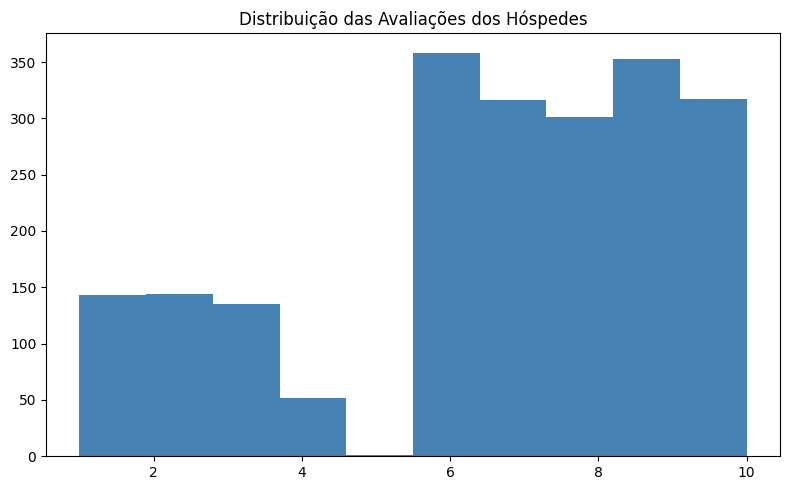

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df_reserva['avaliacao_hospede'], bins=10, color='#4682B4')

plt.title('Distribuição das Avaliações dos Hóspedes')
#plt.xlabel('Avaliação')
#plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

##  `Justificativa dos Gráficos`

- O gráfico de status das reservas permite avaliar perdas operacionais, como cancelamentos e no-show  

- O gráfico de formas de pagamento evidencia o comportamento financeiro dos clientes  

- A distribuição de hóspedes permite identificar o perfil de ocupação das reservas  

- A análise das avaliações indica o nível de satisfação dos clientes  

✅ Esses indicadores foram escolhidos por sua relevância na análise operacional e estratégica da rede hoteleira
``

---
# 📊 PAINEL DE ANÁLISE

#### 
O painel a seguir reúne diferentes indicadores da base de reservas, permitindo uma visão consolidada do comportamento das reservas, perfil dos clientes e nível de satisfação.

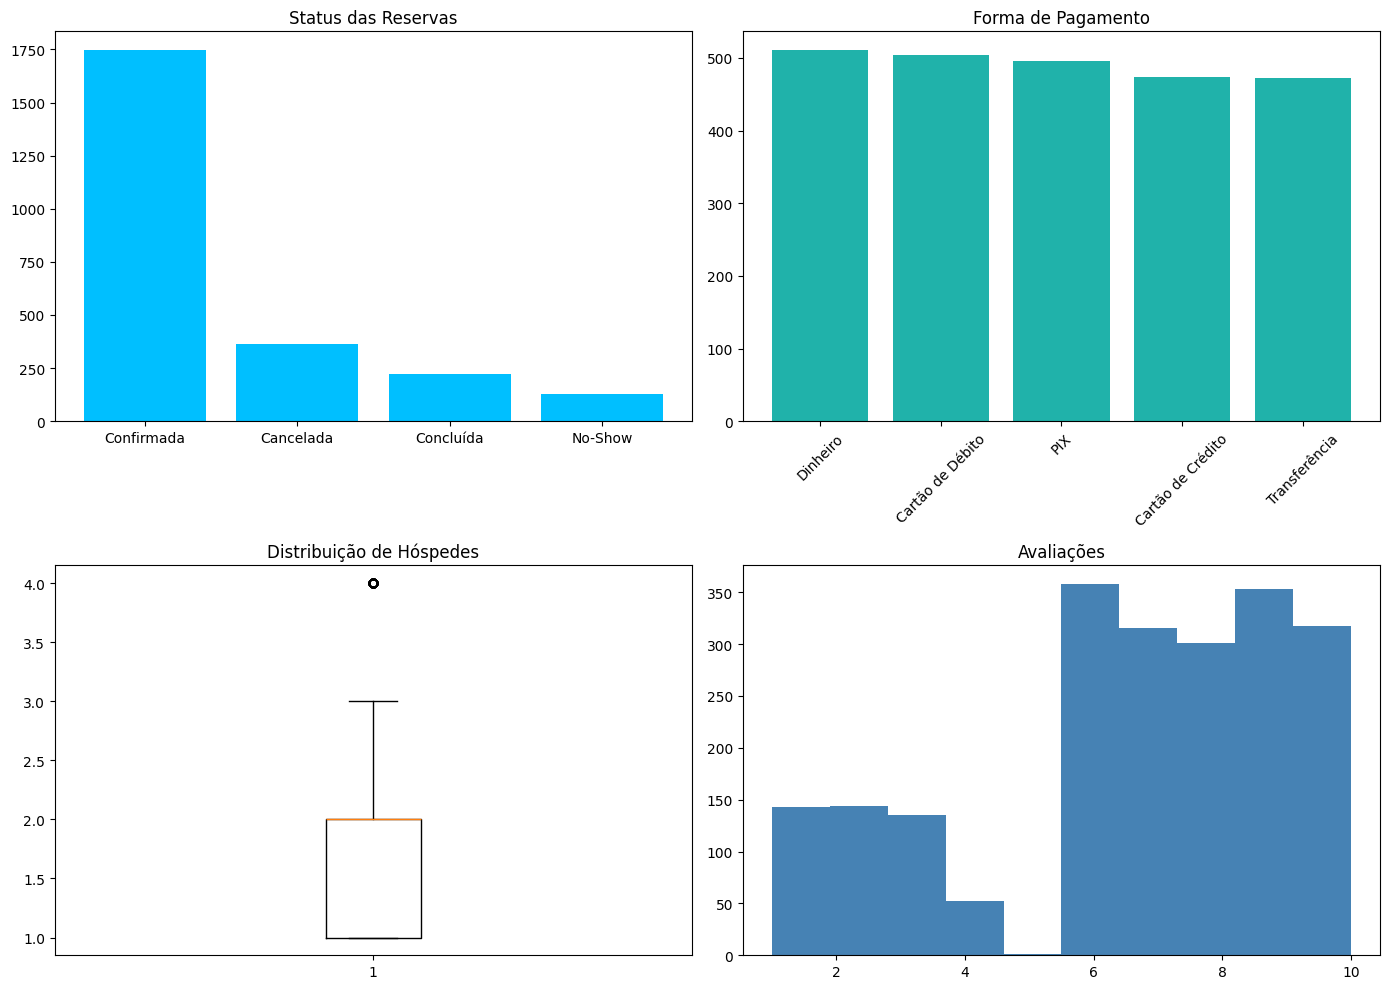

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# --------------------------
# Status
status_counts = df_reserva['status_reserva'].value_counts()
axs[0,0].bar(status_counts.index, status_counts.values, color='#00BFFF')
axs[0,0].set_title('Status das Reservas')

# --------------------------
# Pagamento
pagamento_counts = df_reserva['forma_pagamento'].value_counts()
axs[0,1].bar(pagamento_counts.index, pagamento_counts.values, color='#20B2AA')
axs[0,1].set_title('Forma de Pagamento')
axs[0,1].tick_params(axis='x', rotation=45)

# --------------------------
# Hóspedes
axs[1,0].boxplot(df_reserva['num_hospedes'])
axs[1,0].set_title('Distribuição de Hóspedes')

# --------------------------
# Avaliações
axs[1,1].hist(df_reserva['avaliacao_hospede'], bins=10, color='#4682B4')
axs[1,1].set_title('Avaliações')

plt.tight_layout()
plt.show()

### ✅ ANÁLISE

A análise dos status das reservas mostra que há um alto volume de reservas confirmadas, porém apenas uma parte é efetivamente concluída.

Isso indica perdas operacionais relacionadas a cancelamentos e no-show, impactando diretamente a taxa real de ocupação.

Além disso, a análise das formas de pagamento mostra predominância de determinados métodos, refletindo o comportamento do cliente.

O número de hóspedes evidencia diferentes perfis de uso, enquanto as avaliações indicam o nível geral de satisfação dos clientes.



### ✅ ANÁLISE

A análise mostra que há predominância de determinados meios de pagamento, indicando preferência clara dos clientes.

Métodos como cartão e PIX tendem a concentrar maior volume, refletindo praticidade e aceitação no mercado.

Essa informação é relevante para a operação, pois diferentes formas de pagamento podem impactar custos (taxas de cartão, tempo de compensação) e estratégias comerciais.

✅ Dessa forma, compreender o comportamento dos clientes em relação ao pagamento permite otimizar processos financeiros e melhorar a experiência do cliente.


#
---